In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
from google.colab import files
upload = files.upload()

Saving Dataset for Data Analytics.xlsx to Dataset for Data Analytics (1).xlsx


In [7]:
df = pd.read_excel('Dataset for Data Analytics.xlsx')
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [9]:
print(df.describe(include='all'))

          OrderID                 Date CustomerID  Product     Quantity  \
count        1200                 1200       1200     1200  1200.000000   
unique       1200                  NaN       1189        7          NaN   
top     ORD201183                  NaN     C46651  Printer          NaN   
freq            1                  NaN          2      181          NaN   
mean          NaN  2024-03-22 16:58:48        NaN      NaN     2.945833   
min           NaN  2023-01-01 00:00:00        NaN      NaN     1.000000   
25%           NaN  2023-08-03 18:00:00        NaN      NaN     2.000000   
50%           NaN  2024-03-23 00:00:00        NaN      NaN     3.000000   
75%           NaN  2024-11-08 12:00:00        NaN      NaN     4.000000   
max           NaN  2025-06-30 00:00:00        NaN      NaN     5.000000   
std           NaN                  NaN        NaN      NaN     1.407557   

          UnitPrice ShippingAddress PaymentMethod OrderStatus TrackingNumber  \
count   1200.000000

## Data Preprocessing for Classification

In [10]:
# Drop irrelevant columns for classification
df_processed = df.drop(['OrderID', 'CustomerID', 'ShippingAddress', 'TrackingNumber'], axis=1)

# Extract features from 'Date' column
df_processed['Year'] = df_processed['Date'].dt.year
df_processed['Month'] = df_processed['Date'].dt.month
df_processed['Day'] = df_processed['Date'].dt.day
df_processed['DayOfWeek'] = df_processed['Date'].dt.dayofweek
df_processed = df_processed.drop('Date', axis=1)

# Handle missing values in 'CouponCode' by filling with 'NoCoupon'
df_processed['CouponCode'] = df_processed['CouponCode'].fillna('NoCoupon')

# Separate target variable (y) and features (X)
y = df_processed['OrderStatus']
X = df_processed.drop('OrderStatus', axis=1)

# Apply one-hot encoding to categorical features
X = pd.get_dummies(X, columns=['Product', 'PaymentMethod', 'CouponCode', 'ReferralSource'], drop_first=True)

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("First 5 rows of processed features:")
print(X.head())

Shape of features (X): (1200, 25)
Shape of target (y): (1200,)
First 5 rows of processed features:
   Quantity  UnitPrice  ItemsInCart  TotalPrice  Year  Month  Day  DayOfWeek  \
0         5     570.62            7     2853.10  2023      1    4          2   
1         2     151.35            3      302.70  2024      8   23          4   
2         5     550.68            8     2753.40  2024      2   27          1   
3         1     273.19            5      273.19  2023     10   15          6   
4         4     626.01            8     2504.04  2025      5    8          3   

   Product_Desk  Product_Laptop  ...  PaymentMethod_Debit Card  \
0         False           False  ...                      True   
1         False           False  ...                     False   
2         False           False  ...                     False   
3         False           False  ...                      True   
4         False           False  ...                     False   

   PaymentMethod_Gift C

## Split Data into Training and Testing Sets

In [11]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (840, 25)
X_test shape: (360, 25)
y_train shape: (840,)
y_test shape: (360,)


## Apply a Simple Classification Algorithm (Decision Tree)

In [12]:
# Initialize and train a Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.19

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.28      0.22      0.24        93
   Delivered       0.15      0.17      0.16        63
     Pending       0.16      0.19      0.18        62
    Returned       0.16      0.22      0.18        65
     Shipped       0.18      0.13      0.15        77

    accuracy                           0.19       360
   macro avg       0.19      0.19      0.18       360
weighted avg       0.19      0.19      0.19       360


Confusion Matrix:
[[20 19 19 20 15]
 [11 11 15 15 11]
 [13 12 12 15 10]
 [11 17 12 14 11]
 [17 12 15 23 10]]


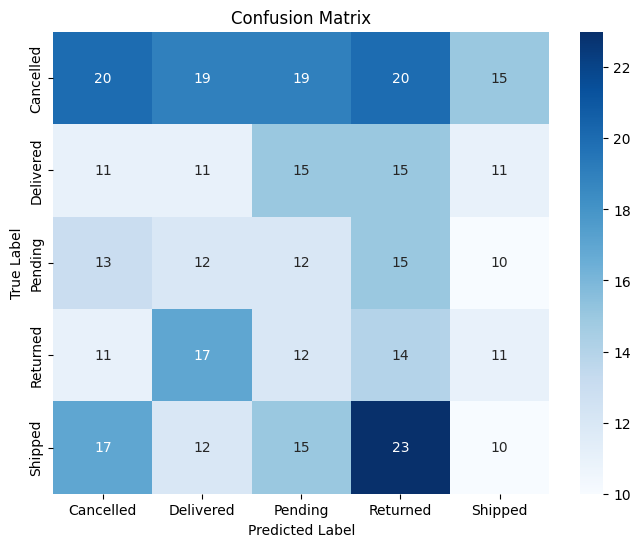

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()